In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

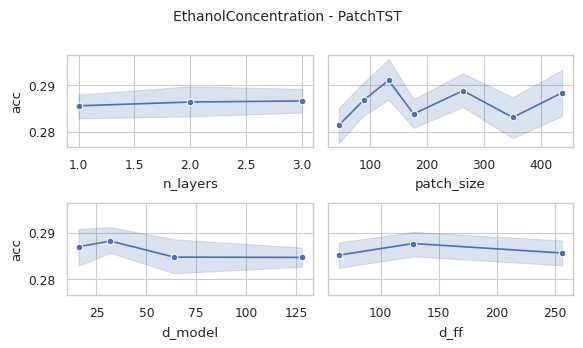

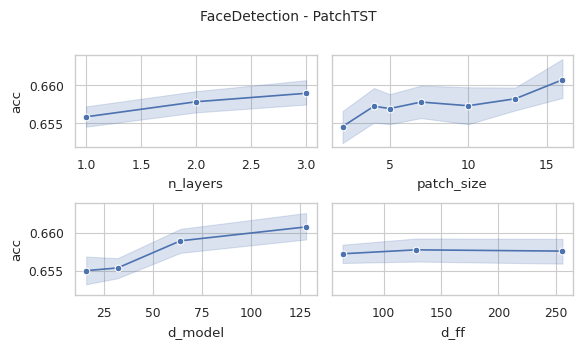

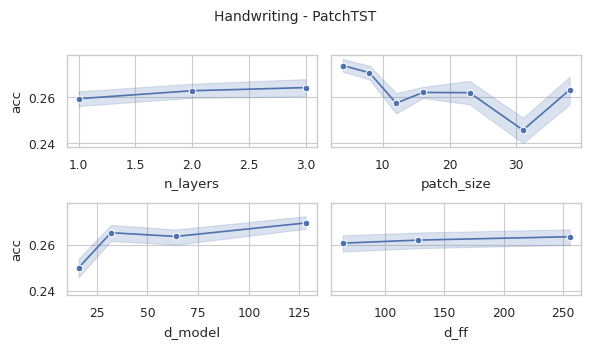

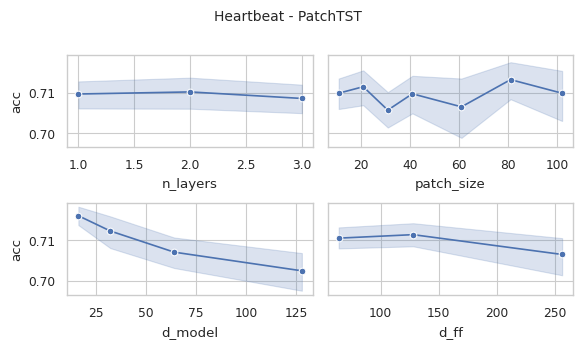

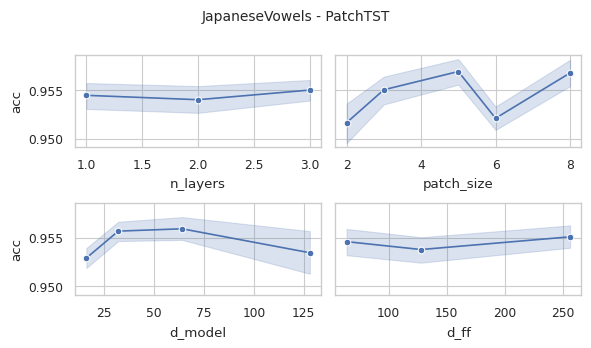

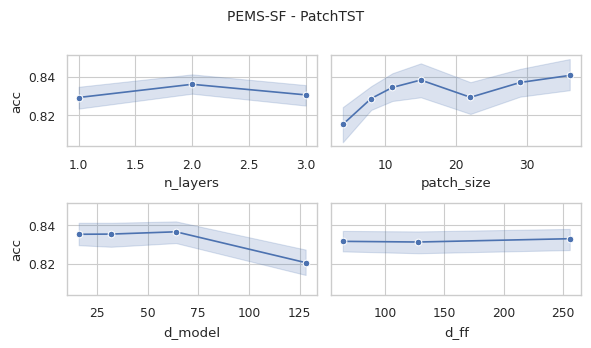

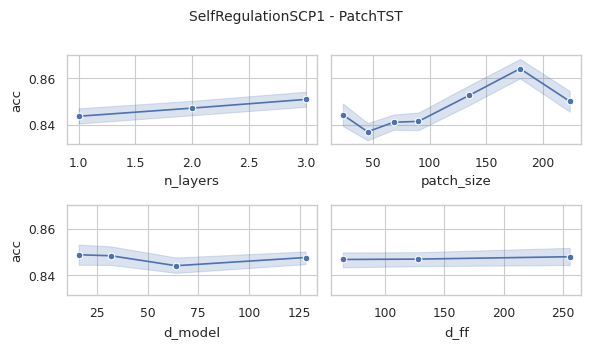

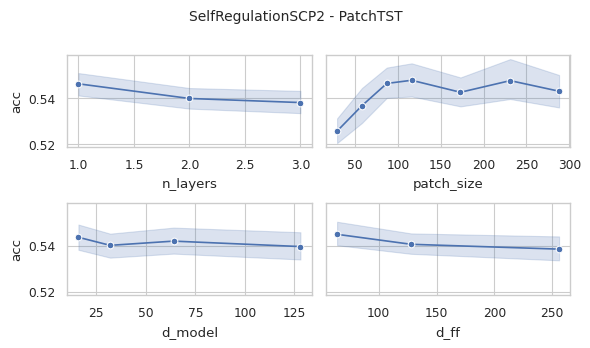

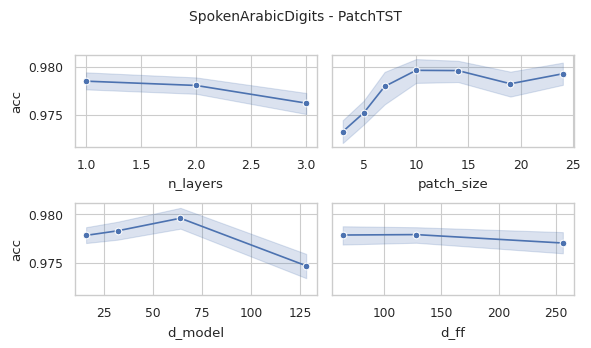

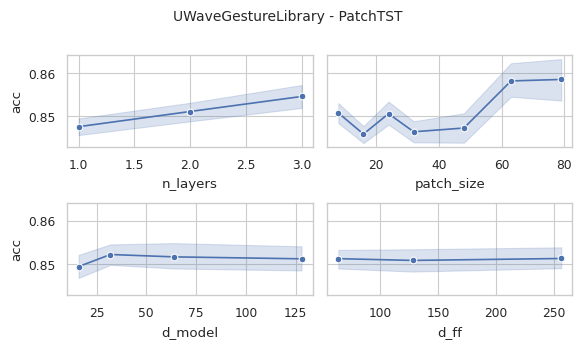

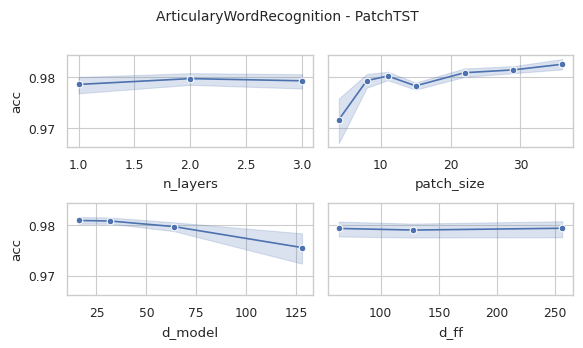

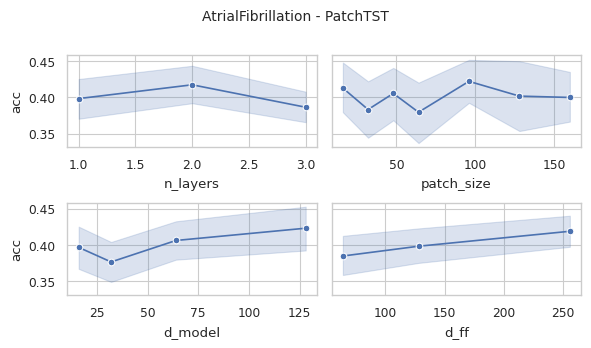

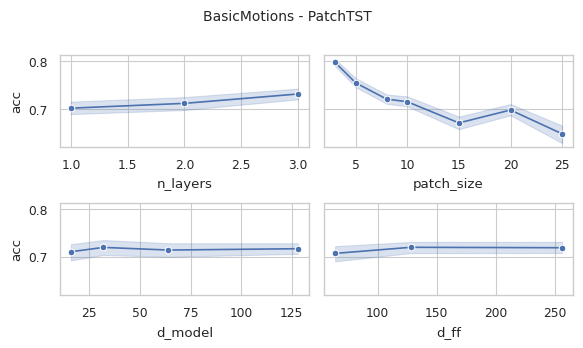

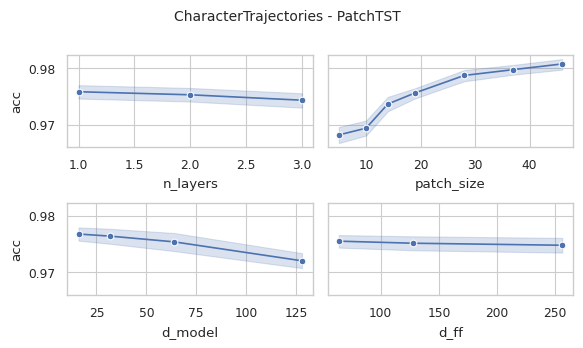

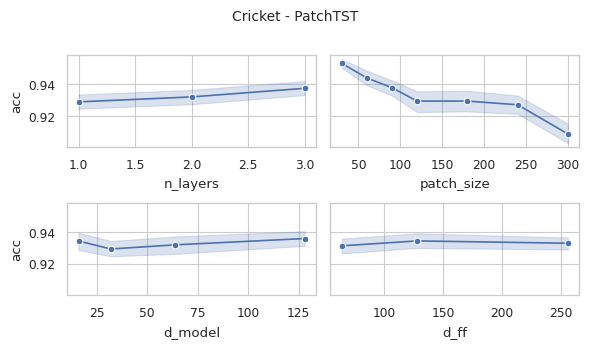

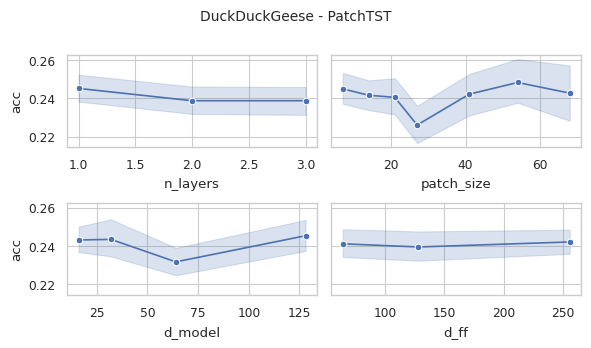

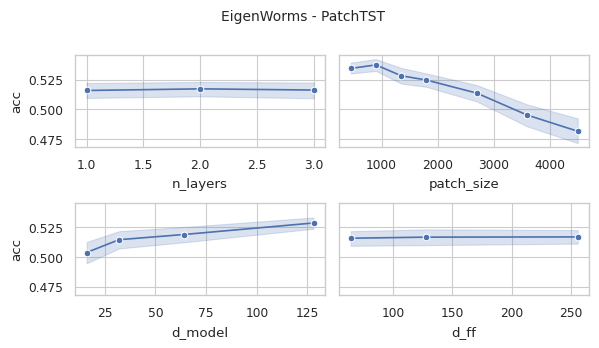

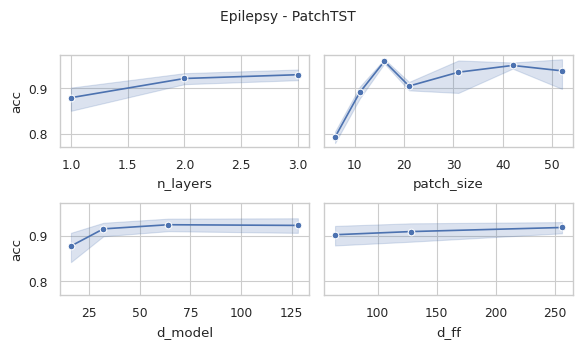

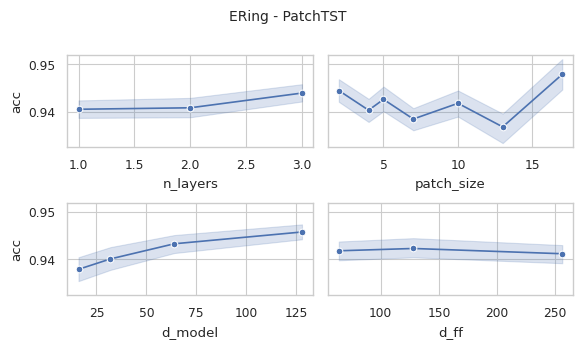

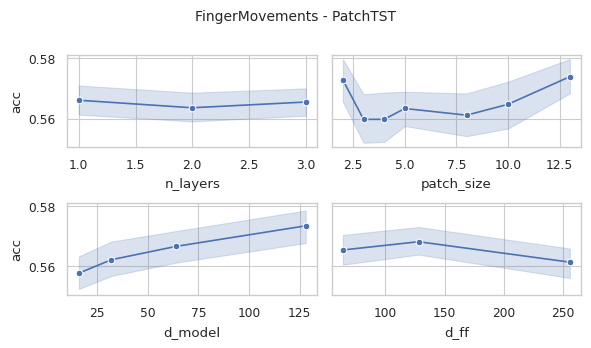

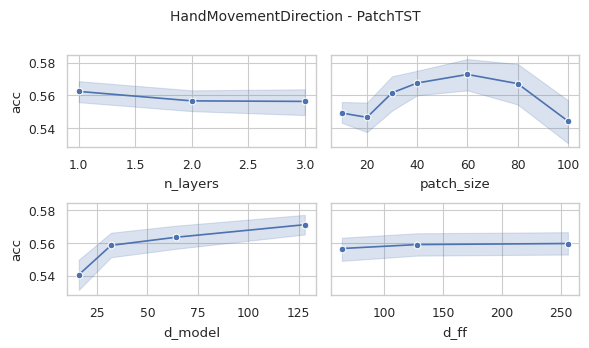

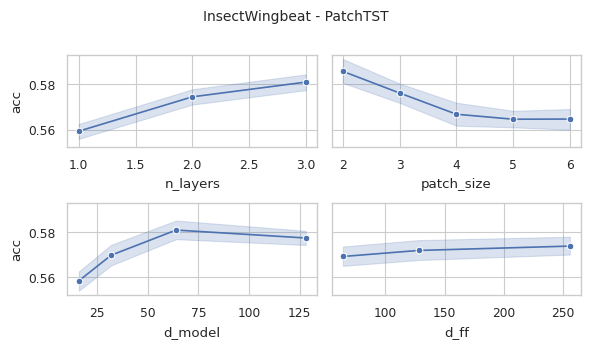

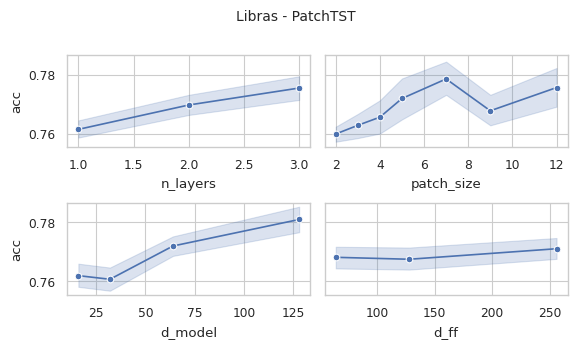

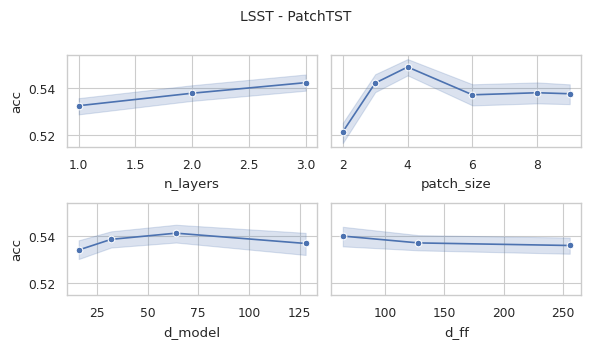

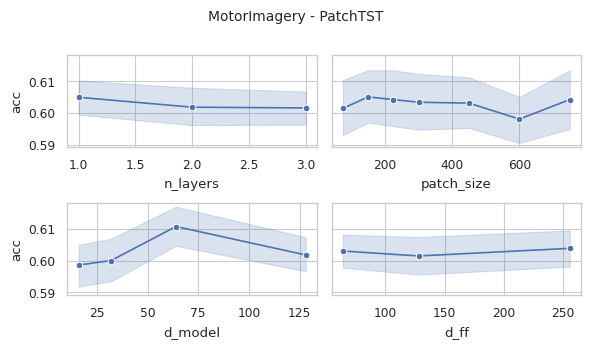

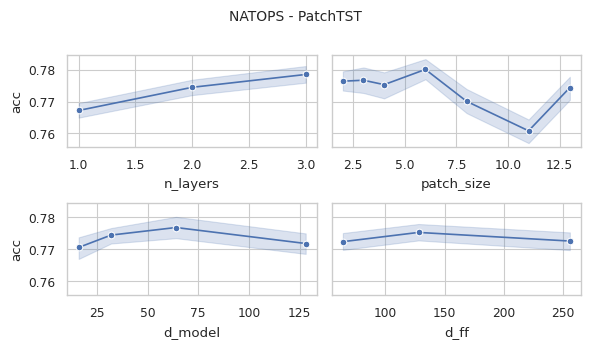

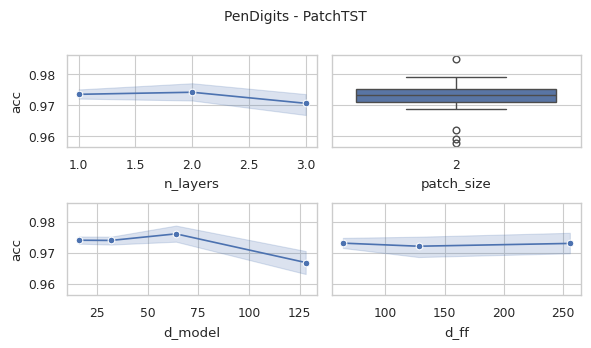

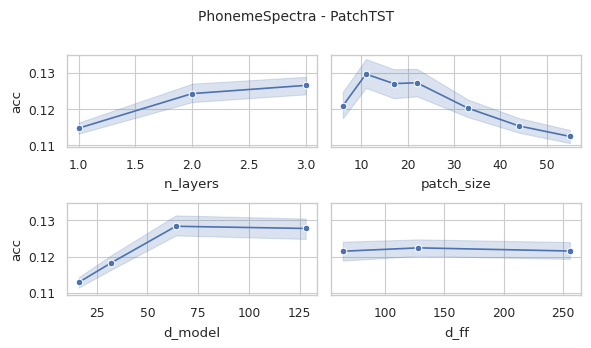

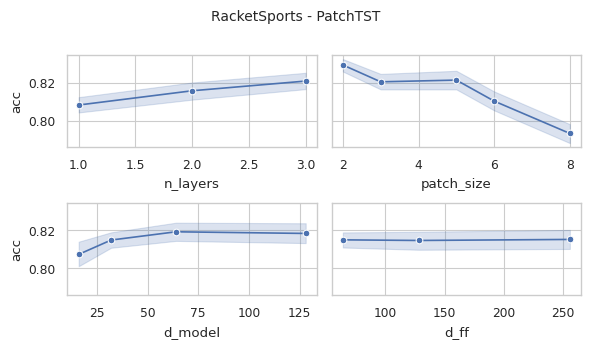

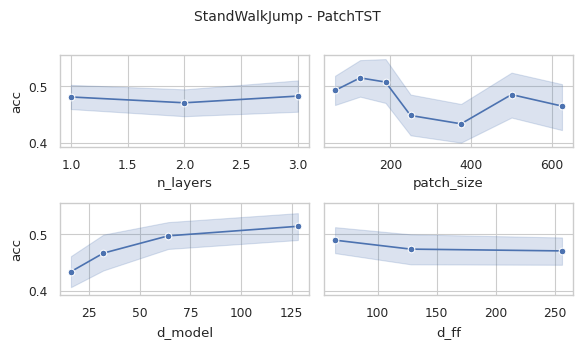

In [4]:
model = 'PatchTST'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('el', ''))
            data_meta[10] = int(data_meta[10].replace('dm', ''))
            data_meta[11] = int(data_meta[11].replace('nh', ''))
            data_meta[12] = int(data_meta[12].replace('df', ''))
            data_meta[13] = int(data_meta[13].replace('ps', ''))
            data_meta[14] = int(data_meta[14].replace('str', ''))

            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'task_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'n_layers': data_meta[9],
                'd_model': data_meta[10],
                'num_heads': data_meta[11],
                'd_ff': data_meta[12],
                'patch_size': data_meta[13],
                'patch_stride': data_meta[14],
                # 'exp': data_meta[15],
                # 'desc': data_meta[16],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['n_layers', 'patch_size', 'd_model', 'd_ff']
    num_cols, num_rows = 2, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    
    

In [5]:
model_configs = {
    "e_layers" : [1, 2, 3],  # default: 3
    "d_model" : [16, 32, 64, 128],  # default: 16, 128
    "d_ff" : [64, 128, 256],  # default: 128, 256
    "patch_size_ratio" : [2.5, 5, 7.5, 10, 15, 20, 25],  # default: about 2.x% ~ 5% of seq_len. patch size is inversely proportional to computational cost
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        n_layers = hyperparameter_combination['e_layers']
        d_model = hyperparameter_combination['d_model']
        d_ff = hyperparameter_combination['d_ff']
        patch_ratio = hyperparameter_combination['patch_size_ratio']

        patch_size = max(2, math.ceil((patch_ratio/100) * seq_len))
        patch_stride = max(1, math.ceil((patch_ratio/100) * seq_len * 1/2))
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['n_layers'] == n_layers)
                & (tmp['d_model'] == d_model)
                & (tmp['d_ff'] == d_ff)
                & (tmp['patch_size'] == patch_size)
                & (tmp['patch_stride'] == patch_stride)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'e_layers': 3, 'd_model': 64, 'd_ff': 128, 'patch_size_ratio': 15}","{'e_layers': 1, 'd_model': 32, 'd_ff': 128, 'patch_size_ratio': 7.5}","{'e_layers': 3, 'd_model': 64, 'd_ff': 256, 'patch_size_ratio': 5}","{'e_layers': 3, 'd_model': 32, 'd_ff': 128, 'patch_size_ratio': 7.5}","{'e_layers': 3, 'd_model': 64, 'd_ff': 64, 'patch_size_ratio': 7.5}","{'e_layers': 3, 'd_model': 64, 'd_ff': 64, 'patch_size_ratio': 20}","{'e_layers': 3, 'd_model': 128, 'd_ff': 64, 'patch_size_ratio': 20}","{'e_layers': 3, 'd_model': 64, 'd_ff': 128, 'patch_size_ratio': 25}","{'e_layers': 2, 'd_model': 128, 'd_ff': 128, 'patch_size_ratio': 7.5}",...,"{'e_layers': 1, 'd_model': 16, 'd_ff': 64, 'patch_size_ratio': 7.5}","{'e_layers': 1, 'd_model': 16, 'd_ff': 128, 'patch_size_ratio': 15}","{'e_layers': 2, 'd_model': 16, 'd_ff': 256, 'patch_size_ratio': 10}","{'e_layers': 1, 'd_model': 32, 'd_ff': 64, 'patch_size_ratio': 20}","{'e_layers': 1, 'd_model': 16, 'd_ff': 64, 'patch_size_ratio': 25}","{'e_layers': 3, 'd_model': 16, 'd_ff': 128, 'patch_size_ratio': 25}","{'e_layers': 1, 'd_model': 128, 'd_ff': 128, 'patch_size_ratio': 25}","{'e_layers': 3, 'd_model': 16, 'd_ff': 64, 'patch_size_ratio': 20}","{'e_layers': 1, 'd_model': 16, 'd_ff': 128, 'patch_size_ratio': 25}","{'e_layers': 1, 'd_model': 16, 'd_ff': 64, 'patch_size_ratio': 15}"
EthanolConcentration,0.326996,0.307985,0.296578,0.277567,0.285171,0.292776,0.269962,0.285171,0.285171,0.30038,...,0.273764,0.304183,0.292776,0.296578,0.296578,0.311787,0.285171,0.281369,0.307985,0.281369
FaceDetection,0.68076,0.661748,0.648978,0.666856,0.65891,0.655221,0.663451,0.660613,0.667991,0.663451,...,0.655221,0.657775,0.654938,0.656073,0.667707,0.672247,0.650965,0.655789,0.665437,0.659762
Handwriting,0.295294,0.278824,0.268235,0.283529,0.252941,0.256471,0.250588,0.261176,0.278824,0.269412,...,0.248235,0.236471,0.278824,0.236471,0.222353,0.242353,0.276471,0.221176,0.215294,0.244706
Heartbeat,0.736585,0.697561,0.717073,0.702439,0.721951,0.687805,0.721951,0.673171,0.721951,0.687805,...,0.712195,0.721951,0.692683,0.726829,0.697561,0.721951,0.673171,0.697561,0.707317,0.721951
JapaneseVowels,0.97027,0.959459,0.956757,0.954054,0.951351,0.962162,0.951351,0.954054,0.959459,0.956757,...,0.954054,0.951351,0.948649,0.951351,0.954054,0.954054,0.956757,0.951351,0.945946,0.956757
PEMS-SF,0.890173,0.855491,0.803468,0.843931,0.884393,0.803468,0.867052,0.815029,0.791908,0.820809,...,0.855491,0.774566,0.820809,0.843931,0.861272,0.855491,0.809249,0.809249,0.82659,0.82659
SelfRegulationSCP1,0.890785,0.836177,0.83959,0.846416,0.846416,0.83959,0.866894,0.853242,0.860068,0.846416,...,0.836177,0.849829,0.836177,0.866894,0.853242,0.849829,0.83959,0.870307,0.83959,0.870307
SelfRegulationSCP2,0.616667,0.527778,0.544444,0.516667,0.538889,0.583333,0.533333,0.522222,0.555556,0.527778,...,0.538889,0.561111,0.544444,0.577778,0.566667,0.55,0.55,0.588889,0.555556,0.527778
SpokenArabicDigits,0.988176,0.981355,0.977717,0.976808,0.978172,0.978627,0.984084,0.969077,0.9809,0.974079,...,0.978627,0.978172,0.98181,0.98181,0.983629,0.976808,0.978172,0.972715,0.978627,0.982719
UWaveGestureLibrary,0.89375,0.85625,0.853125,0.853125,0.853125,0.85,0.859375,0.8625,0.89375,0.84375,...,0.85,0.84375,0.825,0.85,0.8375,0.871875,0.85625,0.853125,0.828125,0.828125


In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'e_layers': 3, 'd_model': 64, 'd_ff': 128, 'patch_size_ratio': 15}"
EthanolConcentration,32.69961977186312,30.79847908745247
FaceDetection,68.0760499432463,66.17480136208853
Handwriting,29.52941176470588,27.88235294117647
Heartbeat,73.65853658536585,69.7560975609756
JapaneseVowels,97.02702702702702,95.94594594594594
PEMS-SF,89.01734104046243,85.54913294797689
SelfRegulationSCP1,89.07849829351537,83.61774744027304
SelfRegulationSCP2,61.66666666666667,52.77777777777778
SpokenArabicDigits,98.81764438381082,98.13551614370168
UWaveGestureLibrary,89.375,85.625
